# Główne importy

In [ ]:
from amplpy import ampl_notebook  # type: ignore
import networkx as nx
import matplotlib.pyplot as plt
import time
from typing import Optional

from net_opt.utils.ampl_data_creator import AMPL_Data_Creator
from net_opt.core.constraints.bandwidth_limit import BandwidthLimit
from net_opt.core.constraints.demand import Demand
from net_opt.core.constraints.path_bandwidth_io_match import PathBandwidthIOMatch
from net_opt.core.constraints.path_edge_bandwidth_kirchhoff_match import PathEdgeBandwidthKirchhoffMatch
from net_opt.core.constraints.path_transponder_bandwidth_weak import PathTransponderBandwidthWeak
from net_opt.core.ea import EA, FastEA
from net_opt.core.mutations.base_mutation import Mutation
from net_opt.core.mutations.gene_mutation import GeneMutation
from net_opt.core.mutations.uniform_crossover import UniformCrossover
from net_opt.core.selections.tournament_selection import TournamentSelection
from net_opt.core.termination_conditions.base_termination_condition import TerminationCondition
from net_opt.core.termination_conditions.max_iterations import MaxIterations
from net_opt.utils.visualisation import visualize_input_data, visualize_population_individual
from net_opt.utils.distributions import get_opt_init_dist
from net_opt.utils.sndlib_parser import SNDlib_Parser

import torch
import pprint
import jaxtyping
import numpy as np

pp = pprint.PrettyPrinter(indent=4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Running on {device} ---")
torch.set_default_device(device)
jaxtyping.config.update("jaxtyping_disable", True)

N = 5
encrypted_bandwidth = 30
regular_bandwidth = 96

mock_transponder_capacities = torch.tensor([40.0, 100.0, 200.0, 400.0, 800.0])
mock_transponder_costs = torch.tensor([1.0, 3.0, 5.0, 9.0, 11.0])
T = mock_transponder_capacities.shape[0]

path_dist, trans_dist = get_opt_init_dist(N, T, encrypted_bandwidth, regular_bandwidth)

selection_config = TournamentSelection(k=3)
termination_config: list[TerminationCondition] = [MaxIterations(iterations=3000)]

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def visualize(logfile_name:str,label_function):
    # Load logs
    with open(logfile_name) as f:
        data = json.load(f)
    fig, axes = plt.subplots(3, 2, figsize=(12, 15), sharex=True)

    population_size = 1000
    plt.yscale("log")
    for i in range(7):
        local_data = data[i][f'{i}']
        logs_avg = np.array(local_data['logs_avg']).reshape(-1, len(local_data['logs_avg'][0]))
        logs_min = np.array(local_data['logs_min']).reshape(-1, len(local_data['logs_min'][0]))
        logs_max = np.array(local_data['logs_max']).reshape(-1, len(local_data['logs_max'][0]))
        n_runs, n_iters = logs_avg.shape

        # Aggregate statistics
        avg_mean = logs_avg.mean(axis=0)
        avg_std  = logs_avg.std(axis=0)
        min_all = logs_min.min(axis=0)
        max_all = logs_max.max(axis=0)
        evaluations = np.arange(n_iters) * population_size
        # Top subplot: mean, min/max, std
        axes[0][0].plot(evaluations, avg_mean, label=f"{label_function(i)}", linewidth=2)
        axes[1][0].plot(evaluations, min_all, linestyle="--",label=f"{label_function(i)}", linewidth=1.5)
        axes[1][1].plot(evaluations, max_all, linestyle="--",label=f"{label_function(i)}",linewidth=1.5)


        # Middle subplot: scatter of averages per run
        for run in range(n_runs):
            axes[2][0].scatter(evaluations, logs_avg[run],label=f"{label_function(i)}", s=20, alpha=0.5)

        axes[2][1].plot(evaluations, avg_std,label=f"{label_function(i)}")
    
    ax = axes[0][0]
    ax.set_ylabel("Cost")
    ax.set_yscale("log")
    ax.set_title("Population avg")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax = axes[1][0]
    ax.set_ylabel("Cost")
    ax.set_yscale("log")
    ax.set_title("Population min")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax = axes[1][1]
    ax.set_ylabel("Cost")
    ax.set_yscale("log")
    ax.set_title("Population max")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[2][0]
    ax.set_xlabel("Total evaluations (iteration × population)")
    ax.set_yscale("log")
    ax.set_ylabel("Average population cost")
    ax.set_title("Scatter of average population per iteration (per run)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Bottom subplot: std deviation
    ax = axes[2][1]
    ax.set_xlabel("Total evaluations (iteration × population)")
    ax.set_ylabel("Std deviation")
    # ax.set_yscale("log")
    ax.set_title("Std deviation of population averages across runs")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Sieci full-mesh

### 5 węzłów

#### Mutacja wykorzystania

In [ ]:
import json
import torch

N = 5  # liczba węzłów w sieci fullmesh
logfile = f"full-mesh-{N}-logs-usage.json"
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool)
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

pop_size = 1000

def create_ea_config(usage_prob: float = 0.5, assign_prob: float = 0.5,cross_usage_prob = 0.5,cross_assign_prob = 0.5):
    mutation_config: list[Mutation] = [
        GeneMutation(path_edge_bandwidth_usage_mut_proba=usage_prob,
                     path_transponder_assignment_mut_proba=assign_prob),
        UniformCrossover(path_edge_bandwidth_usage_cross_proba=cross_usage_prob,
                         path_transponder_assignment_cross_proba=cross_assign_prob),
    ]

    ea_config = FastEA(
        show_vizualisation_every_n_iter=0,
        population_size=pop_size,
        elite_size=50,
        path_edge_bandwidth_usage_init_distribution=path_dist,
        path_transponder_assignment_init_distribution=trans_dist,
        constraints=[
            PathBandwidthIOMatch(),
            PathEdgeBandwidthKirchhoffMatch(),
            PathTransponderBandwidthWeak(),
            Demand(),
            BandwidthLimit(),
        ],
        termination_conditions=termination_config,
        selection_method=selection_config,
        mutation_methods=mutation_config,
        global_constraint_weight=10000,
        device=device,
        log_fitness=True,
    )
    return ea_config

# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(usage_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

##### Krzywe zbieżności

In [ ]:
visualize("full-mesh-5-logs-usage.json",lambda x: probabilities[x])

#### Mutacja przypisania

In [ ]:
import json
import torch

N = 5  # liczba węzłów w sieci fullmesh
logfile = f"full-mesh-{N}-logs-assign.json"
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool)
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

pop_size = 1000

def create_ea_config(usage_prob: float = 0.5, assign_prob: float = 0.5):
    mutation_config: list[Mutation] = [
        GeneMutation(path_edge_bandwidth_usage_mut_proba=usage_prob,
                     path_transponder_assignment_mut_proba=assign_prob),
        UniformCrossover(path_edge_bandwidth_usage_cross_proba=0.5,
                         path_transponder_assignment_cross_proba=0.5),
    ]

    ea_config = FastEA(
        show_vizualisation_every_n_iter=0,
        population_size=pop_size,
        elite_size=50,
        path_edge_bandwidth_usage_init_distribution=path_dist,
        path_transponder_assignment_init_distribution=trans_dist,
        constraints=[
            PathBandwidthIOMatch(),
            PathEdgeBandwidthKirchhoffMatch(),
            PathTransponderBandwidthWeak(),
            Demand(),
            BandwidthLimit(),
        ],
        termination_conditions=termination_config,
        selection_method=selection_config,
        mutation_methods=mutation_config,
        global_constraint_weight=10000,
        device=device,
        log_fitness=True,
    )
    return ea_config

# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

##### Krzywe

In [ ]:
visualize("full-mesh-5-logs-assign.json",lambda x: probabilities[x])


#### Krzyżowanie wykorzystania

In [ ]:
import json
import torch

N = 5  # liczba węzłów w sieci fullmesh
logfile = f"full-mesh-{N}-logs-usage-cross.json"
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool)
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

pop_size = 1000

def create_ea_config(usage_prob: float = 0.5, assign_prob: float = 0.5,cross_usage_prob = 0.5,cross_assign_prob = 0.5):
    mutation_config: list[Mutation] = [
        GeneMutation(path_edge_bandwidth_usage_mut_proba=usage_prob,
                     path_transponder_assignment_mut_proba=assign_prob),
        UniformCrossover(path_edge_bandwidth_usage_cross_proba=cross_usage_prob,
                         path_transponder_assignment_cross_proba=cross_assign_prob),
    ]

    ea_config = FastEA(
        show_vizualisation_every_n_iter=0,
        population_size=pop_size,
        elite_size=50,
        path_edge_bandwidth_usage_init_distribution=path_dist,
        path_transponder_assignment_init_distribution=trans_dist,
        constraints=[
            PathBandwidthIOMatch(),
            PathEdgeBandwidthKirchhoffMatch(),
            PathTransponderBandwidthWeak(),
            Demand(),
            BandwidthLimit(),
        ],
        termination_conditions=termination_config,
        selection_method=selection_config,
        mutation_methods=mutation_config,
        global_constraint_weight=10000,
        device=device,
        log_fitness=True,
    )
    return ea_config

# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_usage_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-5-logs-usage-cross.json",lambda x: probabilities[x])


#### Krzyżowanie przypisanie

In [ ]:
import json
import torch

N = 5  # liczba węzłów w sieci fullmesh
logfile = f"full-mesh-{N}-logs-assign-cross.json"
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool)
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

pop_size = 1000

def create_ea_config(usage_prob: float = 0.5, assign_prob: float = 0.5,cross_usage_prob = 0.5,cross_assign_prob = 0.5):
    mutation_config: list[Mutation] = [
        GeneMutation(path_edge_bandwidth_usage_mut_proba=usage_prob,
                     path_transponder_assignment_mut_proba=assign_prob),
        UniformCrossover(path_edge_bandwidth_usage_cross_proba=cross_usage_prob,
                         path_transponder_assignment_cross_proba=cross_assign_prob),
    ]

    ea_config = FastEA(
        show_vizualisation_every_n_iter=0,
        population_size=pop_size,
        elite_size=50,
        path_edge_bandwidth_usage_init_distribution=path_dist,
        path_transponder_assignment_init_distribution=trans_dist,
        constraints=[
            PathBandwidthIOMatch(),
            PathEdgeBandwidthKirchhoffMatch(),
            PathTransponderBandwidthWeak(),
            Demand(),
            BandwidthLimit(),
        ],
        termination_conditions=termination_config,
        selection_method=selection_config,
        mutation_methods=mutation_config,
        global_constraint_weight=10000,
        device=device,
        log_fitness=True,
    )
    return ea_config

# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-5-logs-assign-cross.json",lambda x: probabilities[x])


### 10 węzłów

In [ ]:
N = 10  # liczba węzłów w sieci fullmesh
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool)
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

pop_size = 1000

def create_ea_config(usage_prob: float = 0.5, assign_prob: float = 0.5,cross_usage_prob = 0.5,cross_assign_prob = 0.5):
    mutation_config: list[Mutation] = [
        GeneMutation(path_edge_bandwidth_usage_mut_proba=usage_prob,
                     path_transponder_assignment_mut_proba=assign_prob),
        UniformCrossover(path_edge_bandwidth_usage_cross_proba=cross_usage_prob,
                         path_transponder_assignment_cross_proba=cross_assign_prob),
    ]

    ea_config = FastEA(
        show_vizualisation_every_n_iter=0,
        population_size=pop_size,
        elite_size=50,
        path_edge_bandwidth_usage_init_distribution=path_dist,
        path_transponder_assignment_init_distribution=trans_dist,
        constraints=[
            PathBandwidthIOMatch(),
            PathEdgeBandwidthKirchhoffMatch(),
            PathTransponderBandwidthWeak(),
            Demand(),
            BandwidthLimit(),
        ],
        termination_conditions=termination_config,
        selection_method=selection_config,
        mutation_methods=mutation_config,
        global_constraint_weight=10000,
        device=device,
        log_fitness=True,
    )
    return ea_config

#### Mutacja wykorzystania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-usage.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(usage_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-10-logs-usage.json",lambda x: probabilities[x])


#### Mutacja przypisania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-assign.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(assign_prob=prob,usage_prob=0.3)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
        # data[idx][f'{idx}']={'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
visualize("full-mesh-10-logs-assign.json",lambda x: probabilities[x])


NameError: name 'N' is not defined

#### Krzyżowanie wykorzystania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-usage-cross.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_usage_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

/tmp/ipykernel_5677/4242449047.py:74: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


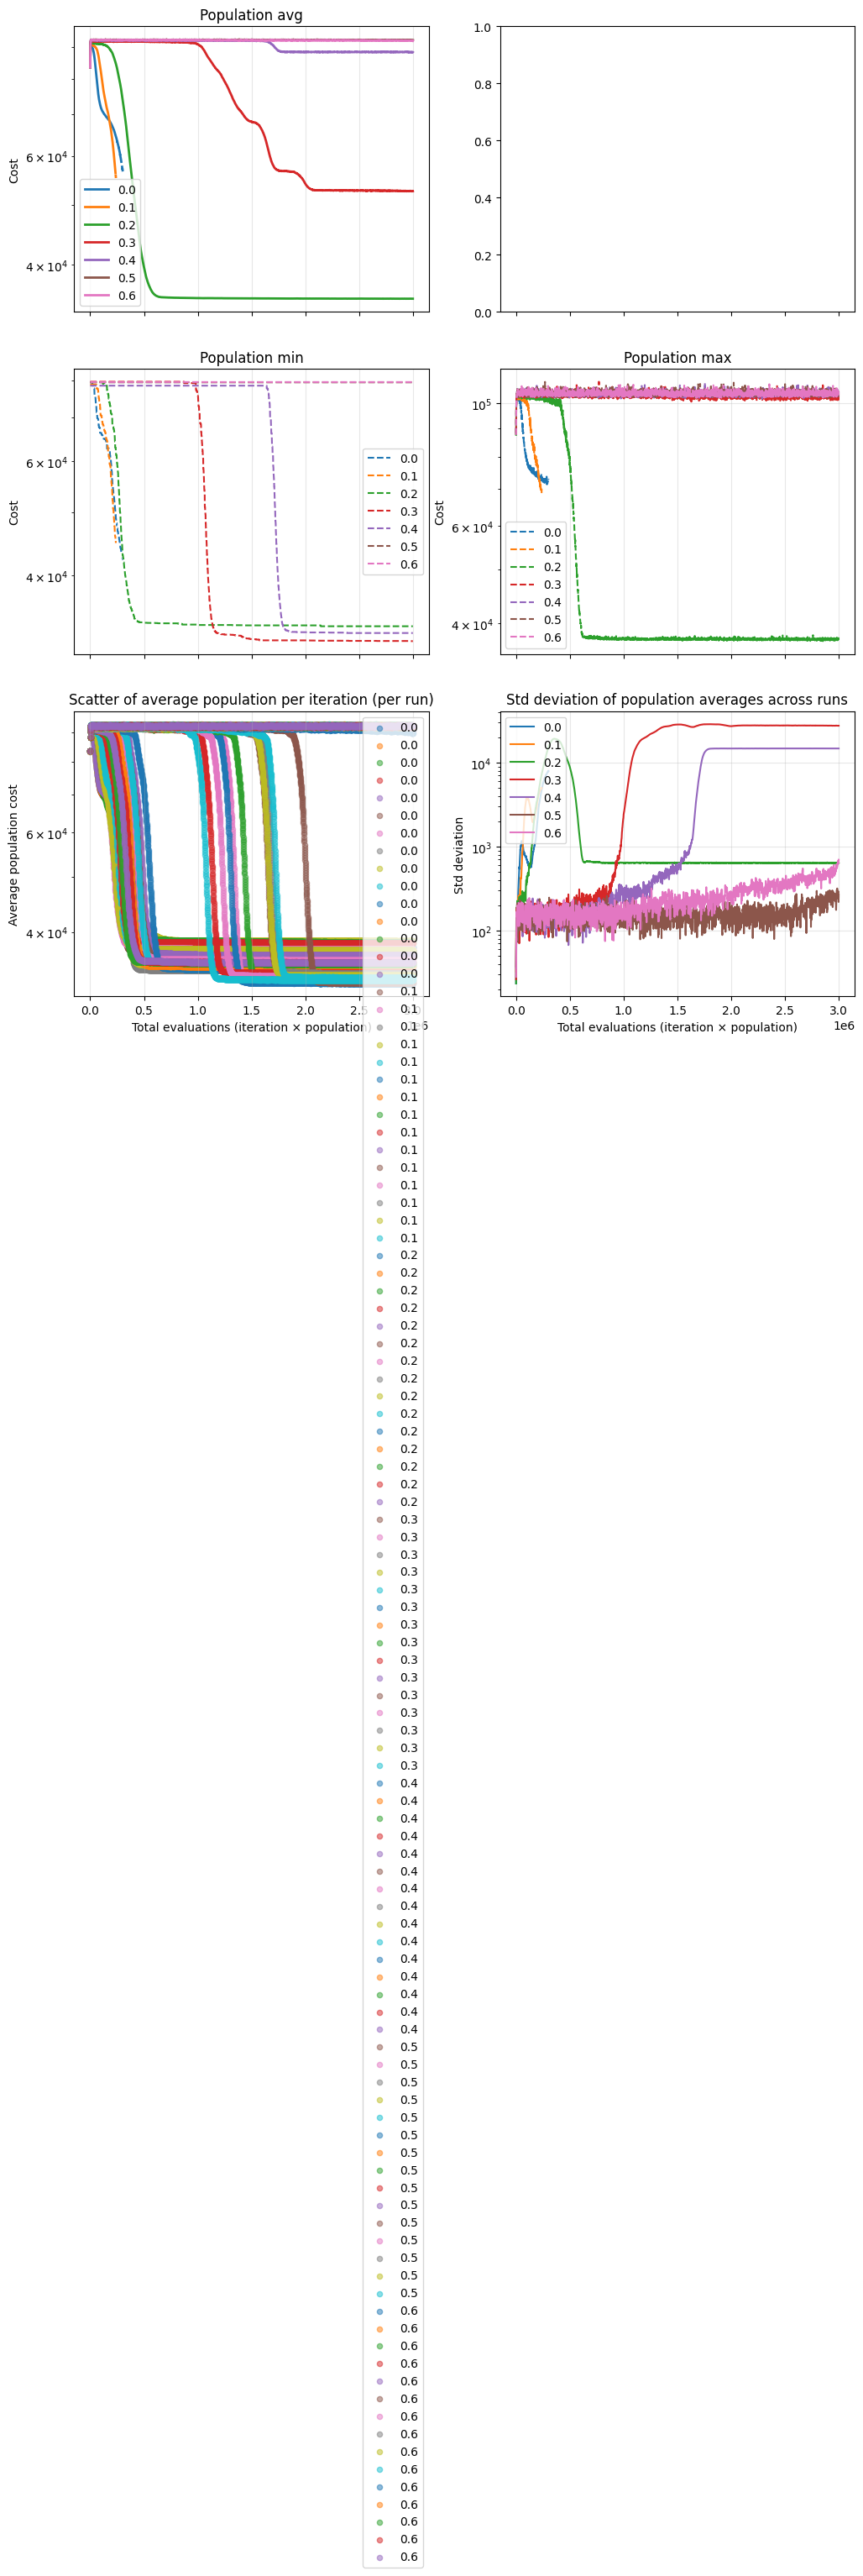

In [13]:
visualize("full-mesh-10-logs-usage-cross.json",lambda x: probabilities[x])


#### Krzyżowanie przypisania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-assign-cross.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-10-logs-assign-cross.json",lambda x: probabilities[x])


### 20 węzłów

In [ ]:
N = 20  # liczba węzłów w sieci fullmesh
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool)
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

pop_size = 1000

def create_ea_config(usage_prob: float = 0.5, assign_prob: float = 0.5,cross_usage_prob = 0.5,cross_assign_prob = 0.5):
    mutation_config: list[Mutation] = [
        GeneMutation(path_edge_bandwidth_usage_mut_proba=usage_prob,
                     path_transponder_assignment_mut_proba=assign_prob),
        UniformCrossover(path_edge_bandwidth_usage_cross_proba=cross_usage_prob,
                         path_transponder_assignment_cross_proba=cross_assign_prob),
    ]

    ea_config = FastEA(
        show_vizualisation_every_n_iter=0,
        population_size=pop_size,
        elite_size=50,
        path_edge_bandwidth_usage_init_distribution=path_dist,
        path_transponder_assignment_init_distribution=trans_dist,
        constraints=[
            PathBandwidthIOMatch(),
            PathEdgeBandwidthKirchhoffMatch(),
            PathTransponderBandwidthWeak(),
            Demand(),
            BandwidthLimit(),
        ],
        termination_conditions=termination_config,
        selection_method=selection_config,
        mutation_methods=mutation_config,
        global_constraint_weight=10000,
        device=device,
        log_fitness=True,
    )
    return ea_config

#### Mutacja wykorzystania 

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-usage.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-20-logs-usage.json",lambda x: probabilities[x])


#### Mutacja przypisania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-assign.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-20-logs-assign.json",lambda x: probabilities[x])


#### Krzyżowanie wykorzystania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-usage-cross.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-20-logs-usage-cross.json",lambda x: probabilities[x])


#### Krzyżwoanie przypisania

In [ ]:
import json
import torch

logfile = f"full-mesh-{N}-logs-assign-cross.json"


# Initialize empty logfile
with open(logfile, "w") as f:
    json.dump([], f)

probabilities = [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for idx, prob in enumerate(probabilities):
    logs_min, logs_max, logs_avg = [], [], []
    for i in range(15):
        print(f"Doing {i} run")
        ea_instance = create_ea_config(cross_assign_prob=prob)
        ea_instance.run(
            encrypted_bandwidth=encrypted_bandwidth,
            regular_bandwidth=regular_bandwidth,
            neigh_matrix=mock_neigh_matrix,
            demand=mock_demand,
            transponder_costs=mock_transponder_costs,
            transponder_capacities=mock_transponder_capacities,
        )
        logs_avg.append([float(x) for x in ea_instance._log_avg])
        logs_min.append([float(x) for x in ea_instance._log_min])
        logs_max.append([float(x) for x in ea_instance._log_max])

    dump_dict = {idx: {'logs_min': logs_min, 'logs_max': logs_max, 'logs_avg': logs_avg}}
    with open(logfile, "r") as f:
        data = json.load(f)
    data.append(dump_dict)
    with open(logfile, "w") as f:
        json.dump(data, f)

In [ ]:
visualize("full-mesh-20-logs-assign-cross.json",lambda x: probabilities[x])
